In [ ]:

# ============================================================================
# CELDA 1: CONFIGURACIÓN INICIAL
# ============================================================================

import torch
print("🔍 Verificando GPU...")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️ GPU no disponible. El entrenamiento será MUY lento.")

# Instalar YOLOv8
print("\n📦 Instalando ultralytics (YOLOv26)...")
!pip install -q ultralytics

# Importar librerías
from ultralytics import YOLO
import os
from IPython.display import Image, display

print("\n✅ Configuración completada!")

🔍 Verificando GPU...
CUDA disponible: True
GPU: Tesla T4
Memoria: 15.64 GB

📦 Instalando ultralytics (YOLOv26)...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

✅ Configuración completada!


In [ ]:
# ============================================================================
# CELDA 2: MONTAR EL DATA
# ============================================================================
from google.colab import files
import zipfile
import os

# 1️⃣ Subir archivo manualmente
uploaded = files.upload()

# 2️⃣ Obtener el nombre real del archivo subido
zip_path = list(uploaded.keys())[0]

# 3️⃣ Crear carpeta de destino
extract_path = '/content/data'
os.makedirs(extract_path, exist_ok=True)

# 4️⃣ Verificación básica
if not zip_path.endswith('.zip'):
    raise ValueError(f"El archivo '{zip_path}' no es un .zip válido")

# 5️⃣ Descomprimir
try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("✅ Dataset descomprimido correctamente en:", extract_path)

except zipfile.BadZipFile:
    print("❌ Error: el archivo no es un zip válido o está corrupto")


Saving 5_Fold_CV_Dataset_Physical.zip to 5_Fold_CV_Dataset_Physical.zip
✅ Dataset descomprimido correctamente en: /content/data


In [ ]:
# ============================================================================
# CELDA 4: CREAR ARCHIVOS YAML PARA CADA FOLD
# ============================================================================

folds = ['fold_0', 'fold_1', 'fold_2']

for fold in folds:
    yaml_path = f'/content/data/5_Fold_CV_Dataset_Physical/{fold}/data.yaml'

    # Contenido corregido con rutas relativas correctas
    yaml_content = f"""# Configuración del dataset - {fold}
path: /content/data/5_Fold_CV_Dataset_Physical/{fold}
train: train/images
val: valid/images

# Clases
nc: 1
names:
  0: huevo
"""
    # Sobrescribir el YAML original
    with open(yaml_path, 'w') as f:
        f.write(yaml_content)

    print(f"✅ {yaml_path} actualizado con rutas correctas para Colab")

✅ /content/data/5_Fold_CV_Dataset_Physical/fold_0/data.yaml actualizado con rutas correctas para Colab
✅ /content/data/5_Fold_CV_Dataset_Physical/fold_1/data.yaml actualizado con rutas correctas para Colab
✅ /content/data/5_Fold_CV_Dataset_Physical/fold_2/data.yaml actualizado con rutas correctas para Colab


In [ ]:
from ultralytics import YOLO

MODEL_SIZE = 'yolo26n.pt'
EPOCHS = 30
BATCH_SIZE = 16
IMG_SIZE = 640

folds = ['fold_0', 'fold_1', 'fold_2']
results_all = []

for fold in folds:
    print(f"\n🚀 Entrenando {fold}...\n")

    # Usar el YAML original que ya corregimos
    data_yaml = f'/content/data/5_Fold_CV_Dataset_Physical/{fold}/data.yaml'

    model = YOLO(MODEL_SIZE)

    results = model.train(
        data=data_yaml,
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        name=f'train_{fold}',
        patience=50,
        save=True,
        plots=True,
        device=0
    )

    results_all.append(results)

print("\n✅ Entrenamiento de los 3 folds completado!")


🚀 Entrenando fold_0...

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/5_Fold_CV_Dataset_Physical/fold_0/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_fold_0, nbs=64, nms=False, opset=None, optimize=False, opt


📊 Resultados del entrenamiento - fold_0:


image 1/194 /content/data/5_Fold_CV_Dataset_Physical/fold_0/valid/images/Egg_X14_jpeg.rf.109f2c205ec1fa2affdde7fc7684b7e8.jpg: 640x480 1 huevo, 66.1ms
image 2/194 /content/data/5_Fold_CV_Dataset_Physical/fold_0/valid/images/Egg_X21_jpeg.rf.237880394b2284ae5c035a8523575405.jpg: 640x480 1 huevo, 11.7ms
image 3/194 /content/data/5_Fold_CV_Dataset_Physical/fold_0/valid/images/Egg_X27_jpeg.rf.cdd33ed3bbaf82de94b140ea16c0869a.jpg: 640x480 18 huevos, 10.4ms
image 4/194 /content/data/5_Fold_CV_Dataset_Physical/fold_0/valid/images/Egg_X29_jpeg.rf.bc30f9f4380b911f4c25234daded4160.jpg: 640x480 1 huevo, 10.0ms
image 5/194 /content/data/5_Fold_CV_Dataset_Physical/fold_0/valid/images/Egg_X2_jpeg.rf.d1ea2bc22f9d5f220daee564dd471ebf.jpg: 640x480 2 huevos, 9.8ms
image 6/194 /content/data/5_Fold_CV_Dataset_Physical/fold_0/valid/images/Egg_X30_jpeg.rf.50c2e33b4aab0e942e76e4cdf3c844af.jpg: 640x480 2 huevos, 17.0ms
image 7/194 /content/data/5_Fold_CV_Dataset_Phys

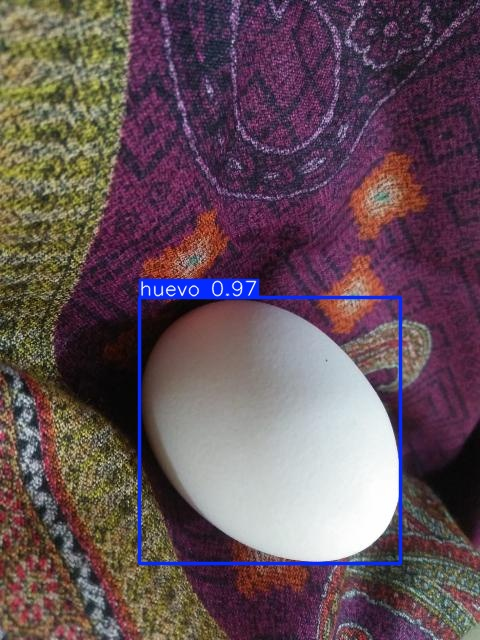


2️⃣ Métricas finales:


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
25,26,354.870,0.33545,0.34002,0.00370,0.95191,0.90566,0.95993,0.89485,0.40419,0.36110,0.00435,0.000350,0.000350,0.000350
26,27,367.075,0.30883,0.31130,0.00324,0.95225,0.91038,0.96167,0.90104,0.37121,0.37338,0.00401,0.000284,0.000284,0.000284
27,28,378.710,0.29547,0.30587,0.00303,0.96527,0.91773,0.96234,0.90481,0.34103,0.37411,0.00350,0.000218,0.000218,0.000218
28,29,390.089,0.26195,0.27638,0.00265,0.95572,0.91623,0.96260,0.90427,0.36473,0.39280,0.00382,0.000152,0.000152,0.000152
29,30,401.989,0.26988,0.30125,0.00281,0.96016,0.90943,0.96257,0.90409,0.32247,0.37310,0.00327,0.000086,0.000086,0.000086



📊 Resultados del entrenamiento - fold_1:


image 1/194 /content/data/5_Fold_CV_Dataset_Physical/fold_1/valid/images/Egg_X0_jpeg.rf.3e5a8514e4cd496df63fd78cd99e2ca5.jpg: 640x480 1 huevo, 10.0ms
image 2/194 /content/data/5_Fold_CV_Dataset_Physical/fold_1/valid/images/Egg_X20_jpeg.rf.32cce16ba056d5216905f0e71232d26b.jpg: 640x480 1 huevo, 11.2ms
image 3/194 /content/data/5_Fold_CV_Dataset_Physical/fold_1/valid/images/Egg_X32_jpeg.rf.993db10809904012a94672956595e6ac.jpg: 640x480 2 huevos, 10.3ms
image 4/194 /content/data/5_Fold_CV_Dataset_Physical/fold_1/valid/images/Egg_X33_jpeg.rf.b7e485d0158ec237dcb046af70272475.jpg: 640x480 1 huevo, 10.1ms
image 5/194 /content/data/5_Fold_CV_Dataset_Physical/fold_1/valid/images/Egg_X34_jpeg.rf.f6689e262e524e5f1387bcc7bc3f666d.jpg: 640x480 2 huevos, 10.2ms
image 6/194 /content/data/5_Fold_CV_Dataset_Physical/fold_1/valid/images/Egg_X38_jpeg.rf.0283d5532da1411a476d12abe707ceb9.jpg: 640x480 1 huevo, 9.7ms
image 7/194 /content/data/5_Fold_CV_Dataset_Physic

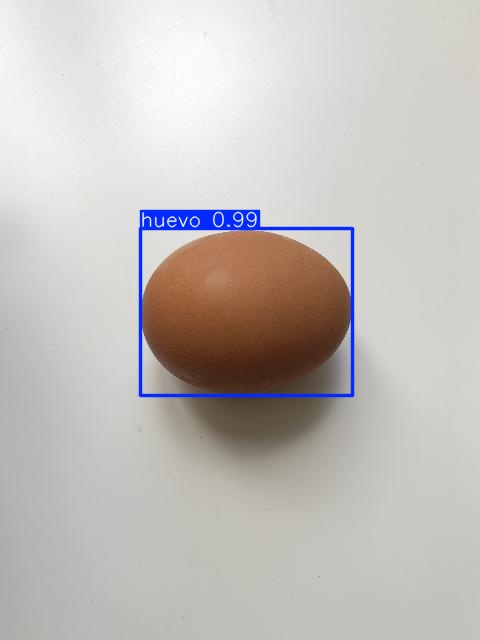


2️⃣ Métricas finales:


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
25,26,351.543,0.30070,0.32806,0.00320,0.91314,0.84694,0.94235,0.87692,0.35053,0.37230,0.00344,0.000350,0.000350,0.000350
26,27,364.004,0.28743,0.28348,0.00300,0.92572,0.82660,0.94025,0.87202,0.38809,0.39094,0.00381,0.000284,0.000284,0.000284
27,28,376.687,0.29125,0.28271,0.00295,0.90927,0.84184,0.93631,0.86793,0.37794,0.39905,0.00371,0.000218,0.000218,0.000218
28,29,388.993,0.28627,0.28228,0.00280,0.93784,0.83673,0.93333,0.86337,0.38162,0.41744,0.00386,0.000152,0.000152,0.000152
29,30,401.511,0.27275,0.28009,0.00273,0.92580,0.82756,0.93219,0.86573,0.37231,0.42819,0.00364,0.000086,0.000086,0.000086



📊 Resultados del entrenamiento - fold_2:


image 1/194 /content/data/5_Fold_CV_Dataset_Physical/fold_2/valid/images/Egg_X12_jpeg.rf.673156b175b7db45ba2b7a3251383fe2.jpg: 640x480 1 huevo, 10.0ms
image 2/194 /content/data/5_Fold_CV_Dataset_Physical/fold_2/valid/images/Egg_X18_jpeg.rf.7f9cc9c5cdd37452406ebcfe3b13fed0.jpg: 640x480 1 huevo, 10.5ms
image 3/194 /content/data/5_Fold_CV_Dataset_Physical/fold_2/valid/images/Egg_X19_jpeg.rf.098730814ca16f05e39f130c5d2f0207.jpg: 640x480 1 huevo, 10.0ms
image 4/194 /content/data/5_Fold_CV_Dataset_Physical/fold_2/valid/images/Egg_X24_jpeg.rf.46bcf3cbdd62fc33e68cd1bf4a3850fe.jpg: 640x480 1 huevo, 10.7ms
image 5/194 /content/data/5_Fold_CV_Dataset_Physical/fold_2/valid/images/Egg_X26_jpeg.rf.2585caa2bc958e118ee2c07ce4907156.jpg: 640x480 1 huevo, 12.4ms
image 6/194 /content/data/5_Fold_CV_Dataset_Physical/fold_2/valid/images/Egg_X46_jpeg.rf.4e3fab75b0a56b2c47a3f8916876ff64.jpg: 640x480 1 huevo, 9.8ms
image 7/194 /content/data/5_Fold_CV_Dataset_Physica

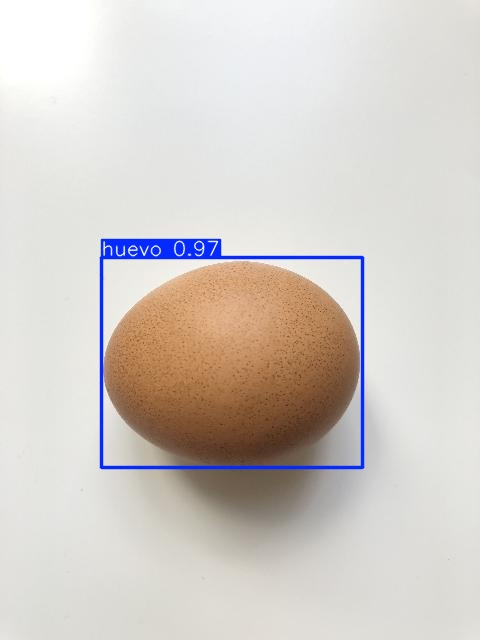


2️⃣ Métricas finales:


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
25,26,356.065,0.34694,0.32771,0.00347,0.93034,0.91579,0.95337,0.87620,0.39746,0.37864,0.00506,0.000350,0.000350,0.000350
26,27,368.605,0.32999,0.31680,0.00336,0.94063,0.92105,0.95304,0.88226,0.37899,0.35659,0.00483,0.000284,0.000284,0.000284
27,28,381.290,0.28808,0.30053,0.00291,0.97942,0.87895,0.95294,0.88198,0.35502,0.36745,0.00443,0.000218,0.000218,0.000218
28,29,393.912,0.27573,0.29229,0.00279,0.98109,0.88947,0.95408,0.88649,0.34619,0.36124,0.00425,0.000152,0.000152,0.000152
29,30,406.393,0.26861,0.28324,0.00266,0.95978,0.91053,0.95420,0.88520,0.34688,0.35257,0.00418,0.000086,0.000086,0.000086


In [ ]:
import glob

# ============================================================================
# CELDA 6: VISUALIZAR RESULTADOS DE LOS 3 FOLDS (predicciones manuales)
# ============================================================================

from ultralytics import YOLO
from IPython.display import display, Image
import os

folds = ['fold_0', 'fold_1', 'fold_2']
dataset_base = '/content/data/5_Fold_CV_Dataset_Physical'

for fold in folds:
    print(f"\n📊 Resultados del entrenamiento - {fold}:\n")

    # Dynamically find the actual training run directory
    # YOLOv8 often appends a number if a directory with the same name exists (e.g., train_fold_0, train_fold_02)
    actual_train_dirs = glob.glob(f'runs/detect/train_{fold}*')
    if not actual_train_dirs:
        print(f"❌ No se encontró ningún directorio de entrenamiento para {fold}.")
        continue
    # Sort to get the latest (highest numbered) run directory
    actual_train_dirs.sort()
    resultados_carpeta = actual_train_dirs[-1]

    best_model_path = os.path.join(resultados_carpeta, 'weights', 'best.pt')
    valid_images = os.path.join(dataset_base, fold, 'valid', 'images')

    if not os.path.exists(best_model_path):
        print(f"❌ Modelo {best_model_path} no encontrado. Verifique la ruta del entrenamiento.")
        continue

    # Cargar modelo entrenado
    model = YOLO(best_model_path)

    # Hacer predicciones sobre la carpeta de validación y guardarlas
    predict_base_dir = f"runs/detect/predict_{fold}"
    os.makedirs(predict_base_dir, exist_ok=True) # Ensure the base project directory exists

    preds = model.predict(source=valid_images, save=True, project=predict_base_dir, name='preds', exist_ok=True)

    # Directly use the save_dir from the results object to locate the prediction folder
    if preds and hasattr(preds[0], 'save_dir') and os.path.isdir(preds[0].save_dir):
        pred_folder = preds[0].save_dir
        pred_images = [f for f in os.listdir(pred_folder) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        if pred_images:
            # Take the first image as an example
            pred_img_path = os.path.join(pred_folder, pred_images[0])
            print("1️⃣ Ejemplo de predicciones en validación:")
            display(Image(filename=pred_img_path))
        else:
            print("❌ No se encontraron imágenes de predicción en la carpeta de resultados.")
    else:
        print("❌ No se pudo determinar la carpeta de resultados de la predicción.")

    # Mostrar métricas si existen results.csv
    results_csv_path = os.path.join(resultados_carpeta, 'results.csv')
    if os.path.exists(results_csv_path):
        print("\n2️⃣ Métricas finales:")
        import pandas as pd
        df = pd.read_csv(results_csv_path)
        display(df.tail(5))
    else:
        print("❌ results.csv no encontrado en el directorio de entrenamiento.")

📤 Sube una imagen para probar el modelo:


Saving banda-transportadora-de-huevo-5.mp4 to banda-transportadora-de-huevo-5.mp4

🔍 Procesando: banda-transportadora-de-huevo-5.mp4

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/681) /content/banda-transportadora-de-huevo-5.mp4: 640x352 3 huevos, 67.7ms
video 1/1 (frame 2/681) /content/banda-transportadora-de-huevo-5.mp4: 640x352 3 huevos, 11.2ms
video 1/1 (frame 3/681) /content/banda-transportadora-de-huevo-5.mp4: 640x352 3 huevos, 9.9ms
video 1/1 (frame 4/681) /content/banda-tr

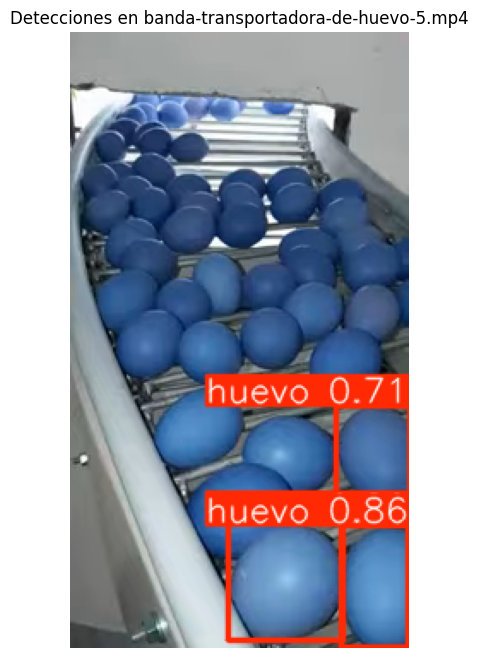

   🥚 Huevos detectados: 3


In [ ]:
# ============================================================================
# CELDA 7: PROBAR MODELO EN IMAGEN
# ============================================================================

from google.colab import files
from PIL import Image as PILImage
import matplotlib.pyplot as plt

print("📤 Sube una imagen para probar el modelo:")
uploaded = files.upload()

# Cargar mejor modelo
modelo_entrenado = YOLO(f'{resultados_carpeta}/weights/best.pt')

# Procesar cada imagen subida
for nombre_archivo in uploaded.keys():
    print(f"\n🔍 Procesando: {nombre_archivo}")

    # Predecir
    resultados = modelo_entrenado.predict(
        nombre_archivo,
        conf=0.5,
        save=True,
        show_labels=True,
        show_conf=True
    )

    # Mostrar resultado
    resultado_img = resultados[0].plot()
    plt.figure(figsize=(12, 8))
    plt.imshow(resultado_img)
    plt.axis('off')
    plt.title(f'Detecciones en {nombre_archivo}')
    plt.show()

    # Mostrar info
    num_detecciones = len(resultados[0].boxes)
    print(f"   🥚 Huevos detectados: {num_detecciones}")


In [ ]:
# ============================================================================
# CELDA 9: DESCARGAR MODELO ENTRENADO
# ============================================================================
"""
📌 Descargar el modelo para usar en tu computadora local
"""

from google.colab import files

# Descargar mejor modelo
modelo_path = f'{resultados_carpeta}/weights/best.pt'
print(f"📥 Descargando modelo: {modelo_path}")
files.download(modelo_path)

print("\n✅ Modelo descargado!")
print("   Ahora puedes usarlo localmente con detect_video.py o detect_realtime.py")

📥 Descargando modelo: runs/detect/train_fold_2/weights/best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Modelo descargado!
   Ahora puedes usarlo localmente con detect_video.py o detect_realtime.py


In [ ]:
# ============================================================================
# CELDA 10: EXPORTAR MODELO A OTROS FORMATOS
# ============================================================================
"""
📌 Exportar modelo para mejor rendimiento
"""

# Cargar modelo
modelo_entrenado = YOLO(f'{resultados_carpeta}/weights/best.pt')

print("🔄 Exportando modelo a diferentes formatos...\n")

# ONNX (compatible con múltiples plataformas)
print("1️⃣ Exportando a ONNX...")
modelo_entrenado.export(format='onnx')
print("   ✅ Exportado a ONNX\n")

# TorchScript (para PyTorch)
print("2️⃣ Exportando a TorchScript...")
modelo_entrenado.export(format='torchscript')
print("   ✅ Exportado a TorchScript\n")

# TFLite (para móviles/edge devices)
print("3️⃣ Exportando a TFLite...")
modelo_entrenado.export(format='tflite')
print("   ✅ Exportado a TFLite\n")

print("✅ Todos los modelos exportados!")
print(f"📁 Ubicación: {resultados_carpeta}/weights/")

# Listar archivos
!ls -lh {resultados_carpeta}/weights/

🔄 Exportando modelo a diferentes formatos...

1️⃣ Exportando a ONNX...
Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from 'runs/detect/train_fold_2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 348ms
Prepared 4 packages in 7.68s
Installed 4 packages in 301ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.90

requirements: AutoUpdate success ✅ 9.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take e

/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: slimming with onnxslim 0.1.90...
ONNX: export success ✅ 10.9s, saved as 'runs/detect/train_fold_2/weights/best.onnx' (9.4 MB)

Export complete (11.3s)
Results saved to /content/runs/detect/train_fold_2/weights
Predict:         yolo predict task=detect model=runs/detect/train_fold_2/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs/detect/train_fold_2/weights/best.onnx imgsz=640 data=/content/data/5_Fold_CV_Dataset_Physical/fold_2/data.yaml  
Visualize:       https://netron.app
   ✅ Exportado a ONNX

2️⃣ Exportando a TorchScript...
Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from 'runs/detect/train_fold_2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)

TorchScript: starting export with torch 2.10.0+cu128...
TorchScript: export success ✅ 2.6s, saved as 'runs/detec

/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: export success ✅ 1.7s, saved as 'runs/detect/train_fold_2/weights/best.onnx' (9.4 MB)
Unzipping calibration_image_sample_data_20x128x128x3_float32.npy.zip to /content/calibration_image_sample_data_20x128x128x3_float32.npy...: 100% ━━━━━━━━━━━━ 1/1 52.3files/s 0.0s
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.8...
Saved artifact at 'runs/detect/train_fold_2/weights/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 640, 640, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 300, 6), dtype=tf.float32, name=None)
Captures:
  134866201628880: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  134866201627344: TensorSpec(shape=(3, 3, 3, 16), dtype=tf.float32, name=None)
  134866201628112: TensorSpec(shape=(16,), dtype=tf.float32, name=None)
  134866201633296: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  134866201633680: TensorSpec(shape=(3, 3, 1

In [ ]:
# ============================================================================
# CELDA 11: LIMPIAR Y HACER BACKUP
# ============================================================================
"""
📌 Comprimir resultados y hacer backup
"""

import shutil

print("📦 Comprimiendo resultados...")

# Crear archivo ZIP
nombre_zip = 'modelo_huevos_backup'
shutil.make_archive(nombre_zip, 'zip', resultados_carpeta)

print(f"✅ Backup creado: {nombre_zip}.zip")
print(f"   Tamaño: {os.path.getsize(nombre_zip + '.zip') / 1e6:.2f} MB")

# Descargar backup
files.download(f'{nombre_zip}.zip')

print("\n💾 Backup descargado!")
print("   Guárdalo en un lugar seguro por si necesitas los resultados después.")


📦 Comprimiendo resultados...
✅ Backup creado: modelo_huevos_backup.zip
   Tamaño: 54.64 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


💾 Backup descargado!
   Guárdalo en un lugar seguro por si necesitas los resultados después.
